In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]
        xi = self.transform(img)
        xj = self.transform(img)
        return xi, xj

train_base = datasets.CIFAR10(root="./data", train=True, download=True)
train_dataset = SimCLRDataset(train_base, train_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

class SimCLR(nn.Module):
    def __init__(self, projection_dim=8):
        super().__init__()
        self.encoder = models.resnet18(pretrained=False)
        dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1), h

def info_nce_loss(z_i, z_j, temperature=0.5):
    batch_size = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)                # [2B, D]
    sim = torch.matmul(z, z.T) / temperature        # [2B, 2B]
    mask = (~torch.eye(2*batch_size, device=sim.device).bool()).float()
    exp_sim = torch.exp(sim) * mask
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
    positives = torch.cat([
        torch.diag(sim, batch_size),
        torch.diag(sim, -batch_size)
    ], dim=0)
    loss = -positives + torch.log(exp_sim.sum(dim=1))
    return loss.mean()

model = SimCLR(projection_dim=8).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

num_epochs = 60
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for xi, xj in train_loader:
        xi = xi.to(device, non_blocking=True)
        xj = xj.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            zi, _ = model(xi)
            zj, _ = model(xj)
            loss = info_nce_loss(zi, zj, temperature=0.5)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "simclr_model.pth")

eval_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
eval_dataset = datasets.CIFAR10(root="./data", train=False, download=False, transform=eval_transform)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

model = SimCLR(projection_dim=8).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.load_state_dict(torch.load("simclr_model.pth"))
model.eval()

all_labels = []
all_embeddings = []
with torch.no_grad():
    for imgs, labels in eval_loader:
        imgs = imgs.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            z, _ = model(imgs)               # z.shape = [B, 8]
        all_embeddings.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

X = np.concatenate(all_labels, axis=0)           # shape [N]
Y = np.concatenate(all_embeddings, axis=0)       # shape [N, 8]

print("X shape (labels):", X.shape)
print("Y shape (embeddings):", Y.shape)

100%|██████████| 170M/170M [00:04<00:00, 40.7MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warn

Epoch 1/60, Loss: 5.7230
Epoch 2/60, Loss: 5.5766
Epoch 3/60, Loss: 5.4374
Epoch 4/60, Loss: 5.3868
Epoch 5/60, Loss: 5.3434
Epoch 6/60, Loss: 5.2871
Epoch 7/60, Loss: 5.2652
Epoch 8/60, Loss: 5.2506
Epoch 9/60, Loss: 5.2155
Epoch 10/60, Loss: 5.1897
Epoch 11/60, Loss: 5.1699
Epoch 12/60, Loss: 5.1624
Epoch 13/60, Loss: 5.1486
Epoch 14/60, Loss: 5.1289
Epoch 15/60, Loss: 5.1274
Epoch 16/60, Loss: 5.1118
Epoch 17/60, Loss: 5.1046
Epoch 18/60, Loss: 5.0918
Epoch 19/60, Loss: 5.0892
Epoch 20/60, Loss: 5.0782
Epoch 21/60, Loss: 5.0704
Epoch 22/60, Loss: 5.0630
Epoch 23/60, Loss: 5.0670
Epoch 24/60, Loss: 5.0593
Epoch 25/60, Loss: 5.0524
Epoch 26/60, Loss: 5.0523
Epoch 27/60, Loss: 5.0443
Epoch 28/60, Loss: 5.0368
Epoch 29/60, Loss: 5.0378
Epoch 30/60, Loss: 5.0322
Epoch 31/60, Loss: 5.0246
Epoch 32/60, Loss: 5.0180
Epoch 33/60, Loss: 5.0173
Epoch 34/60, Loss: 5.0150
Epoch 35/60, Loss: 5.0079
Epoch 36/60, Loss: 5.0067
Epoch 37/60, Loss: 5.0066
Epoch 38/60, Loss: 5.0026
Epoch 39/60, Loss: 5.

/tmp/ipython-input-1249441660.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


X shape (labels): (10000,)
Y shape (embeddings): (10000, 8)


100%|██████████| 11/11 [00:14<00:00,  1.32s/it]


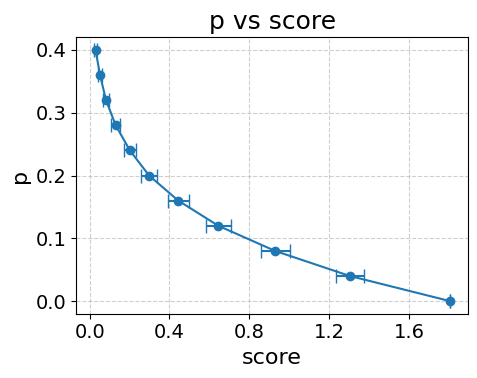

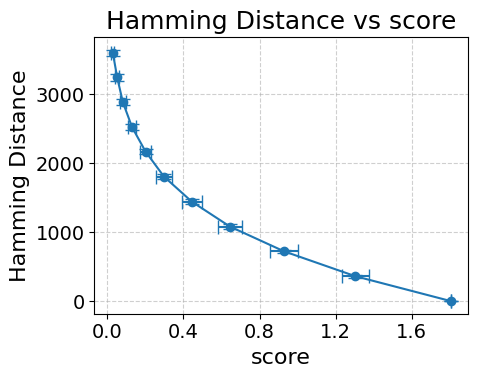

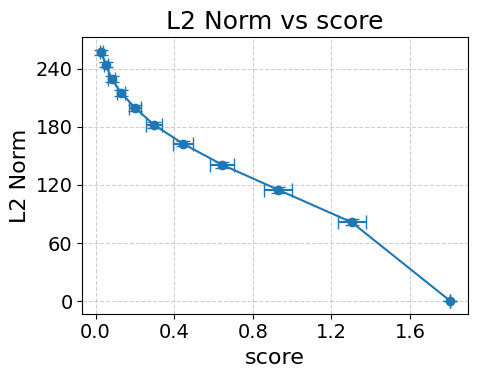

In [3]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from tqdm import tqdm

def compute_avg_polyarea(labels: np.ndarray,
                         embeddings: np.ndarray,
                         p: float,
                         random_state: int = None) -> tuple:
    rng = np.random.default_rng(random_state)

    X_hat = labels.copy()
    for i, j in enumerate(labels):
        if rng.random() > p:
            X_hat[i] = rng.integers(10)

    hamming_dist = np.sum(X_hat != labels)
    l2_norm = np.linalg.norm(X_hat - labels)

    avg_embs = []
    for lab in np.unique(labels):
        mask = (X_hat == lab)
        if not np.any(mask):
            continue
        avg_embs.append(embeddings[mask].mean(axis=0))
    avg_embs = np.vstack(avg_embs)

    hull = ConvexHull(avg_embs)
    return hull.volume, hamming_dist, l2_norm

p_values = np.arange(0.6, 1.0 + 1e-8, 0.04)
seeds = np.arange(0, 101)

mean_areas    = []
std_areas     = []
mean_hamming  = []
std_hamming   = []
mean_l2       = []
std_l2        = []

for p in tqdm(p_values):
    areas = []
    hams  = []
    l2s   = []
    for seed in seeds:
        area, ham, l2 = compute_avg_polyarea(X, 10 * Y, p, random_state=int(seed))
        areas.append(area)
        hams.append(ham)
        l2s.append(l2)
    areas = np.array(areas)
    hams  = np.array(hams)
    l2s   = np.array(l2s)

    mean_areas.append(areas.mean())
    std_areas.append(areas.std(ddof=1))
    mean_hamming.append(hams.mean())
    std_hamming.append(hams.std(ddof=1))
    mean_l2.append(l2s.mean())
    std_l2.append(l2s.std(ddof=1))

mean_areas   = np.array(mean_areas)
std_areas    = np.array(std_areas)
mean_hamming = np.array(mean_hamming)
std_hamming  = np.array(std_hamming)
mean_l2      = np.array(mean_l2)
std_l2       = np.array(std_l2)

from matplotlib.ticker import MaxNLocator

# Base font size
plt.rcParams.update({'font.size': 14})

# Common settings
figsize = (5, 4)
markersize = 6
elinewidth = 1.5
capsize = 5
grid_args = {'which': 'major', 'linestyle': '--', 'linewidth': 0.8, 'alpha': 0.6}

# 1) p vs score
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(
    mean_areas,
    1 - np.array(p_values),
    xerr=std_areas,
    fmt='-o',
    capsize=capsize,
    markersize=markersize,
    elinewidth=elinewidth,
    label='p'
)
ax.set_xlabel('score', fontsize=16)
ax.set_ylabel('p', fontsize=16)
ax.set_title('p vs score', fontsize=18)
ax.grid(**grid_args)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
plt.tight_layout()

# 2) Hamming Distance vs score
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(
    mean_areas,
    mean_hamming,
    xerr=std_areas,
    yerr=std_hamming,
    fmt='-o',
    capsize=capsize,
    markersize=markersize,
    elinewidth=elinewidth
)
ax.set_xlabel('score', fontsize=16)
ax.set_ylabel('Hamming Distance', fontsize=16)
ax.set_title('Hamming Distance vs score', fontsize=18)
ax.grid(**grid_args)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
plt.tight_layout()

# 3) L2 Norm vs score
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(
    mean_areas,
    mean_l2,
    xerr=std_areas,
    yerr=std_l2,
    fmt='-o',
    capsize=capsize,
    markersize=markersize,
    elinewidth=elinewidth
)
ax.set_xlabel('score', fontsize=16)
ax.set_ylabel('L2 Norm', fontsize=16)
ax.set_title('L2 Norm vs score', fontsize=18)
ax.grid(**grid_args)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
plt.tight_layout()

plt.show()

100%|██████████| 11/11 [00:08<00:00,  1.29it/s]


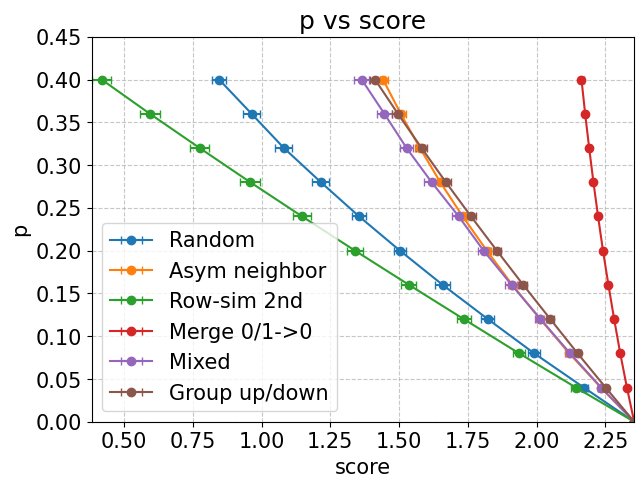

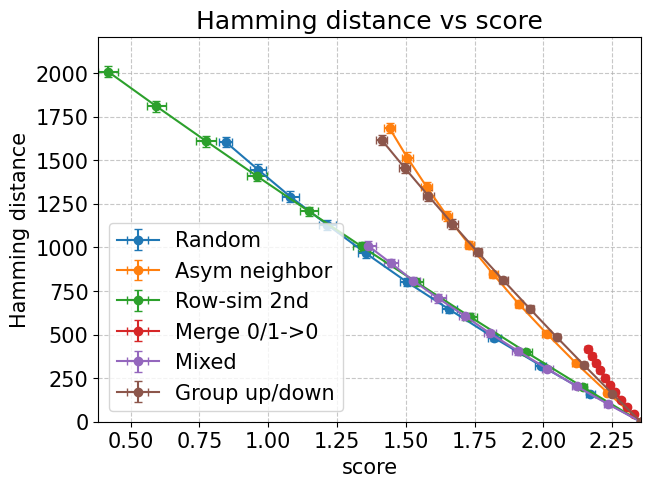

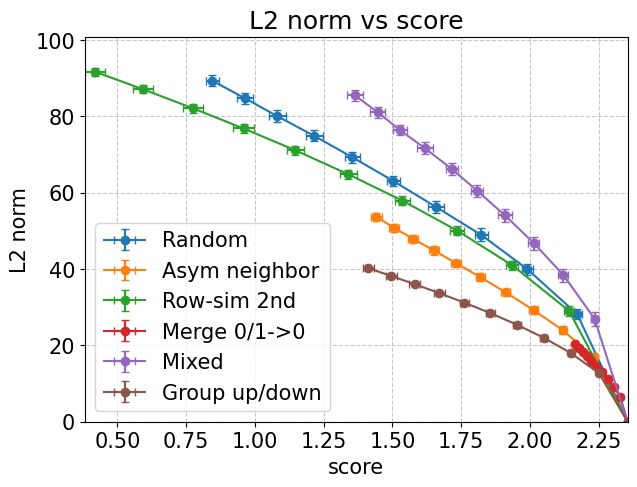

In [5]:
# %%
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, QhullError
from numpy.linalg import norm
from tqdm import tqdm

# -----------------------------
# Synthetic dataset (2D embeddings for hull area)
# -----------------------------
rng = np.random.default_rng(123)
n = 5000
d = 5
ps = np.arange(0.6, 1.0 + 1e-8, 0.04)
seeds = np.arange(0, 101)

# True labels X ~ Uniform
X = rng.integers(0, d, size=n)

# Class centroids on a circle for 2D embeddings
angles = np.linspace(0, 2*np.pi, d, endpoint=False)
centroids = np.stack([np.cos(angles), np.sin(angles)], axis=1)  # (d,2)

# Embeddings: cluster around centroids with noise
embeddings = centroids[X] + 0.25 * rng.standard_normal((n, 2))

# A row-stochastic kernel P used only to infer X-space similarity (not to generate Y here)
P = rng.random((d, d))
P = P / P.sum(axis=1, keepdims=True)

# Precompute class "neighbor" maps and X-space second-class via cosine similarity of P-rows
neighbor_plus = np.arange(d) + 1
neighbor_plus[-1] = d - 1
neighbor_minus = np.arange(d) - 1
neighbor_minus[0] = 0

row_norm = np.linalg.norm(P, axis=1, keepdims=True) + 1e-12
P_unit = P / row_norm
S = P_unit @ P_unit.T
np.fill_diagonal(S, -np.inf)
second_class = S.argmax(axis=1)  # most similar other class for each x

# -----------------------------
# Human-like confusion policy P_human(xhat | x)
# -----------------------------
def human_like_confusion(
    d=5,
    diag_strength=25.0,   # diagonal prior mass (keep original)
    off_strength=1.2,     # base off-diagonal mass
    beta=5.0,             # locality emphasis on ring
    default_bias=0.20,    # extra mass to default label
    default_label=0,      # default/salient label index
    upcode_alpha=1.0,     # mild upcoding preference (j > i)
    topology="ring",
    rng=None,
):
    rng = np.random.default_rng() if rng is None else rng
    idx = np.arange(d)
    if topology == "ring":
        dist = np.minimum(np.abs(idx[:, None] - idx[None, :]),
                          d - np.abs(idx[:, None] - idx[None, :]))
    elif topology == "line":
        dist = np.abs(idx[:, None] - idx[None, :])
    else:
        dist = np.zeros((d, d))
    S_sim = -dist.astype(float)

    Alpha = np.full((d, d), off_strength, float)
    np.fill_diagonal(Alpha, diag_strength)

    small = 1e-8
    for x in range(d):
        neigh = np.exp(beta * (S_sim[x] - S_sim[x].max()))
        up = np.exp(upcode_alpha * (np.arange(d) - x))
        bias = np.zeros(d); bias[default_label] = default_bias * diag_strength
        Alpha[x] = np.maximum(Alpha[x] + neigh + up + bias, small)
        # ensure diagonal remains largest to reflect higher accuracy
        Alpha[x, x] = max(Alpha[x, x], Alpha[x].max() + 1.0)

    Ph = np.zeros((d, d))
    for x in range(d):
        Ph[x] = rng.dirichlet(Alpha[x])
    return Ph

P_human = human_like_confusion(
    d=d,
    diag_strength=25.0,
    off_strength=1.2,
    beta=5.0,
    default_bias=0.20,
    default_label=0,
    upcode_alpha=1.0,
    topology="ring",
    rng=rng,
)

def sample_rowwise(probs, rng):
    """Given probs shape (k, d) with row sums 1, return one categorical sample per row."""
    u = rng.random(probs.shape[0])
    cs = np.cumsum(probs, axis=1)
    return (u[:, None] > cs).sum(axis=1)

# -----------------------------
# Manipulators (operate in X-space to produce X_hat)
# -----------------------------
def manip_uniform(labels, mask, rng):
    """Random replacement (uniform over classes)."""
    xh = labels.copy()
    xh[~mask] = rng.integers(0, d, size=(~mask).sum())
    return xh

def manip_asym_neighbor(labels, mask, rng):
    """85% shift to +1 neighbor; otherwise random non-self."""
    xh = labels.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        toss = rng.random(idx.size)
        go_neighbor = toss < 0.85
        xh[idx[go_neighbor]] = np.minimum(labels[idx[go_neighbor]] + 1, d - 1)
        rest = idx[~go_neighbor]
        if rest.size:
            choices = rng.integers(0, d-1, size=rest.size)
            choices += (choices >= labels[rest]).astype(int)
            xh[rest] = choices
    return xh

def manip_row_sim_2nd(labels, mask, rng):
    """Map to the most similar other class by cosine similarity of P rows."""
    xh = labels.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        xh[idx] = second_class[labels[idx]]
    return xh

def manip_merge_01_to_0(labels, mask, rng):
    """Merge classes {0,1} into 0 on corrupted items."""
    xh = labels.copy()
    idx = np.where(~mask & np.isin(labels, [0, 1]))[0]
    if idx.size:
        xh[idx] = 0
    return xh

def manip_human_like(labels, mask, rng):
    """Sample X_hat from P_human(xhat | x) for corrupted entries."""
    xh = labels.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        probs = P_human[labels[idx]]  # (k, d)
        xh[idx] = sample_rowwise(probs, rng)
    return xh

def manip_group_policy(labels, mask, rng):
    """Split population into two random groups: half +1, half -1."""
    Z = rng.integers(0, 2, size=labels.size)
    xh = labels.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        up_idx = idx[Z[idx] == 1]
        dn_idx = idx[Z[idx] == 0]
        if up_idx.size:
            xh[up_idx] = np.minimum(labels[up_idx] + 1, d - 1)
        if dn_idx.size:
            xh[dn_idx] = np.maximum(labels[dn_idx] - 1, 0)
    return xh

manips = {
    "Random": manip_uniform,
    "Asym neighbor": manip_asym_neighbor,
    "Row-sim 2nd": manip_row_sim_2nd,
    "Merge 0/1->0": manip_merge_01_to_0,
    "Mixed": manip_human_like,     # <-- replaced Upcoding with Human-like
    "Group up/down": manip_group_policy,
}

# -----------------------------
# Metric: area of convex hull of class mean embeddings
# -----------------------------
def convex_hull_area_of_means(labels_hat, embs):
    uniq = np.unique(labels_hat)
    means = []
    for lab in uniq:
        mask = (labels_hat == lab)
        if np.any(mask):
            means.append(embs[mask].mean(axis=0))
    means = np.vstack(means) if len(means) else np.empty((0, 2))
    if means.shape[0] < 3:
        return 0.0
    try:
        hull = ConvexHull(means)
        return float(hull.volume)  # area in 2D
    except QhullError:
        return 0.0

# -----------------------------
# Sweep p and seeds for each manipulation
# -----------------------------
stats = {name: {"area_mean": [], "area_std": [],
                "ham_mean": [],  "ham_std": [],
                "l2_mean": [],   "l2_std": []}
         for name in manips}

for p in tqdm(ps):
    for name, fn in manips.items():
        areas, hams, l2s = [], [], []
        for seed in range(len(seeds)):
            rg = np.random.default_rng(seeds[seed])
            mask = rg.random(n) < p
            xh = fn(X, mask, rg)
            areas.append(convex_hull_area_of_means(xh, embeddings))
            hams.append(np.sum(xh != X))
            l2s.append(norm(xh - X))
        areas, hams, l2s = map(np.asarray, (areas, hams, l2s))
        stats[name]["area_mean"].append(areas.mean())
        stats[name]["area_std"].append(areas.std(ddof=1))
        stats[name]["ham_mean"].append(hams.mean())
        stats[name]["ham_std"].append(hams.std(ddof=1))
        stats[name]["l2_mean"].append(l2s.mean())
        stats[name]["l2_std"].append(l2s.std(ddof=1))

# Convert lists to arrays
for name in manips:
    for k in stats[name]:
        stats[name][k] = np.asarray(stats[name][k])

# -----------------------------
# Plotting with identical box size
# -----------------------------
plt.rcParams.update({'font.size': 15})
figsize = (7, 5)
capsize = 3

# 统一 x 范围
x_min = min((stats[name]["area_mean"] - stats[name]["area_std"]).min() for name in manips)
x_max = max((stats[name]["area_mean"] + stats[name]["area_std"]).max() for name in manips)
X_LIM = (x_min, x_max)

Y_LIM1 = (0, 0.45)
Y_LIM2 = (0, max(stats[name]["ham_mean"].max() for name in manips)*1.1)
Y_LIM3 = (0, max(stats[name]["l2_mean"].max() for name in manips)*1.1)

def finalize(ax, xlabel, ylabel, title, ylim):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
    ax.legend()
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*ylim)

# 1) p vs score
fig1, ax1 = plt.subplots(figsize=figsize)
for name in manips:
    ax1.errorbar(stats[name]["area_mean"], 1 - ps,
                 xerr=stats[name]["area_std"],
                 fmt='-o', capsize=capsize, label=name)
finalize(ax1, 'score', 'p', 'p vs score', Y_LIM1)

# 2) Hamming vs score
fig2, ax2 = plt.subplots(figsize=figsize)
for name in manips:
    ax2.errorbar(stats[name]["area_mean"], stats[name]["ham_mean"],
                 xerr=stats[name]["area_std"], yerr=stats[name]["ham_std"],
                 fmt='-o', capsize=capsize, label=name)
finalize(ax2, 'score', 'Hamming distance', 'Hamming distance vs score', Y_LIM2)

# 3) L2 vs score
fig3, ax3 = plt.subplots(figsize=figsize)
for name in manips:
    ax3.errorbar(stats[name]["area_mean"], stats[name]["l2_mean"],
                 xerr=stats[name]["area_std"], yerr=stats[name]["l2_std"],
                 fmt='-o', capsize=capsize, label=name)
finalize(ax3, 'score', 'L2 norm', 'L2 norm vs score', Y_LIM3)

plt.show()
